# Step 7: Business Simulation & Cost-Benefit Analysis



### 7.1  Assign Transaction Costs

Assume: Average fraudulent transaction value = ₹4,500.

Assume: Cost of investigating a flagged transaction (False Positive) = ₹150 (analyst time).

Using your confusion matrix on X_test, calculate:

Money saved = TP × ₹4,500  (fraud caught)

Investigation cost = (TP + FP) × ₹150  (all flagged transactions reviewed)

Money lost = FN × ₹4,500  (fraud missed)

Net benefit = Money saved − Investigation cost




In [6]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_excel("creditcard.xlsx", engine="openpyxl")

print(df.shape)
df.head()

(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [7]:
df["Amount_log"] = np.log1p(df["Amount"])
df["Hour"] = ((df["Time"] % 86400) // 3600).astype(int)

df = df.drop(columns=["Time", "Amount"])

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df[["Amount_log", "Hour"]] = scaler.fit_transform(
    df[["Amount_log", "Hour"]]
)

In [9]:
X = df.drop("Class", axis=1)
y = df["Class"]

print(X.shape)
print(y.shape)

(284807, 30)
(284807,)


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (227845, 30)
X_test : (56962, 30)
y_train: (227845,)
y_test : (56962,)


In [11]:
print(type(X_train))
print(type(y_train))

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>


In [13]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

# Calculate class weight
ratio = (y_train == 0).sum() / (y_train == 1).sum()

# Base model
xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    scale_pos_weight=ratio
)

# Parameter grid
param_grid = {
    "n_estimators":[100,200,300],
    "max_depth":[3,4,5,6],
    "learning_rate":[0.01,0.05,0.1],
    "subsample":[0.6,0.8,1.0],
    "colsample_bytree":[0.6,0.8,1.0]
}

search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=15,
    scoring="average_precision",
    cv=3,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

best_xgb = search.best_estimator_

print("Best Parameters:")
print(search.best_params_)

Best Parameters:
{'subsample': 0.8, 'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.1, 'colsample_bytree': 0.8}


In [15]:
import numpy as np
from sklearn.metrics import precision_recall_curve, f1_score

# Predicted probabilities
y_prob = best_xgb.predict_proba(X_test)[:, 1]

# Precision-Recall Curve
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

# Find threshold with highest F1
f1_scores = []

for threshold in thresholds:
    y_pred = (y_prob >= threshold).astype(int)
    f1_scores.append(f1_score(y_test, y_pred))

best_index = np.argmax(f1_scores)

best_threshold = thresholds[best_index]

print("Best Threshold:", best_threshold)
print("Best F1 Score:", f1_scores[best_index])

Best Threshold: 0.95583636
Best F1 Score: 0.8695652173913043


In [16]:
# Predict fraud probabilities
y_prob = best_xgb.predict_proba(X_test)[:, 1]

# Apply F1-optimal threshold
y_pred = (y_prob >= best_threshold).astype(int)

In [17]:
cm = confusion_matrix(y_test, y_pred)

TN, FP, FN, TP = cm.ravel()

print("Confusion Matrix")
print(cm)

print("\nTN =", TN)
print("FP =", FP)
print("FN =", FN)
print("TP =", TP)

Confusion Matrix
[[56858     6]
 [   18    80]]

TN = 56858
FP = 6
FN = 18
TP = 80


In [18]:
# Business assumptions
fraud_amount = 4500
investigation_cost = 150

# Money Saved
money_saved = TP * fraud_amount

# Investigation Cost
review_cost = (TP + FP) * investigation_cost

# Money Lost
money_lost = FN * fraud_amount

# Net Benefit
net_benefit = money_saved - review_cost

print("Money Saved (₹):", money_saved)
print("Investigation Cost (₹):", review_cost)
print("Money Lost (₹):", money_lost)
print("Net Benefit (₹):", net_benefit)

Money Saved (₹): 360000
Investigation Cost (₹): 12900
Money Lost (₹): 81000
Net Benefit (₹): 347100


In [19]:
business = pd.DataFrame({

    "Metric":[
        "True Positives",
        "False Positives",
        "False Negatives",
        "Money Saved (₹)",
        "Investigation Cost (₹)",
        "Money Lost (₹)",
        "Net Benefit (₹)"
    ],

    "Value":[
        TP,
        FP,
        FN,
        money_saved,
        review_cost,
        money_lost,
        net_benefit
    ]

})

print(business)

                   Metric   Value
0          True Positives      80
1         False Positives       6
2         False Negatives      18
3         Money Saved (₹)  360000
4  Investigation Cost (₹)   12900
5          Money Lost (₹)   81000
6         Net Benefit (₹)  347100


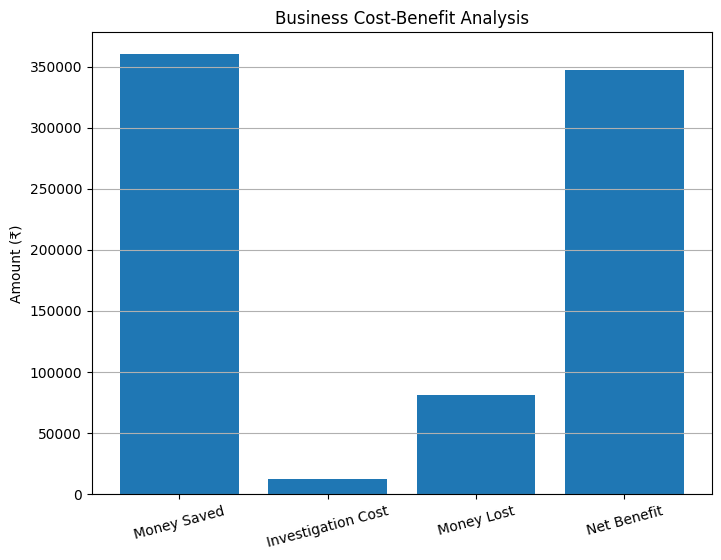

In [20]:
import matplotlib.pyplot as plt

labels = [
    "Money Saved",
    "Investigation Cost",
    "Money Lost",
    "Net Benefit"
]

values = [
    money_saved,
    review_cost,
    money_lost,
    net_benefit
]

plt.figure(figsize=(8,6))

plt.bar(labels, values)

plt.title("Business Cost-Benefit Analysis")

plt.ylabel("Amount (₹)")

plt.xticks(rotation=15)

plt.grid(axis="y")

plt.show()


### 7.2  Threshold Sensitivity

Repeat the above calculation for 5 different thresholds: 0.1, 0.2, 0.3, 0.5, your F1-optimal threshold.

Present results as a table with columns: Threshold, TP, FP, FN, Money Saved, Investigation Cost, Money Lost, Net Benefit.

Which threshold gives the highest Net Benefit? Is it the same as the F1-optimal threshold?

Write 3 sentences interpreting the result in plain English for a Paytm risk manager who does not know what F1-Score means.


In [21]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix

In [22]:
# Predict probabilities
y_prob = best_xgb.predict_proba(X_test)[:, 1]

In [23]:
fraud_amount = 4500
investigation_cost = 150

In [24]:
# If best_threshold is not available, use 0.5 temporarily
# best_threshold = 0.5

thresholds = [0.1, 0.2, 0.3, 0.5, best_threshold]

results = []

for threshold in thresholds:

    y_pred = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    money_saved = tp * fraud_amount

    review_cost = (tp + fp) * investigation_cost

    money_lost = fn * fraud_amount

    net_benefit = money_saved - review_cost

    results.append([
        threshold,
        tp,
        fp,
        fn,
        money_saved,
        review_cost,
        money_lost,
        net_benefit
    ])

business_df = pd.DataFrame(
    results,
    columns=[
        "Threshold",
        "TP",
        "FP",
        "FN",
        "Money Saved",
        "Investigation Cost",
        "Money Lost",
        "Net Benefit"
    ]
)

print(business_df)

   Threshold  TP  FP  FN  Money Saved  Investigation Cost  Money Lost  \
0   0.100000  87  63  11       391500               22500       49500   
1   0.200000  84  38  14       378000               18300       63000   
2   0.300000  84  26  14       378000               16500       63000   
3   0.500000  84  16  14       378000               15000       63000   
4   0.955836  80   6  18       360000               12900       81000   

   Net Benefit  
0       369000  
1       359700  
2       361500  
3       363000  
4       347100  


In [25]:
best_business = business_df.sort_values(
    by="Net Benefit",
    ascending=False
)

print(best_business)

print("\nBest Threshold for Business:")

print(best_business.iloc[0]["Threshold"])

   Threshold  TP  FP  FN  Money Saved  Investigation Cost  Money Lost  \
0   0.100000  87  63  11       391500               22500       49500   
3   0.500000  84  16  14       378000               15000       63000   
2   0.300000  84  26  14       378000               16500       63000   
1   0.200000  84  38  14       378000               18300       63000   
4   0.955836  80   6  18       360000               12900       81000   

   Net Benefit  
0       369000  
3       363000  
2       361500  
1       359700  
4       347100  

Best Threshold for Business:
0.1


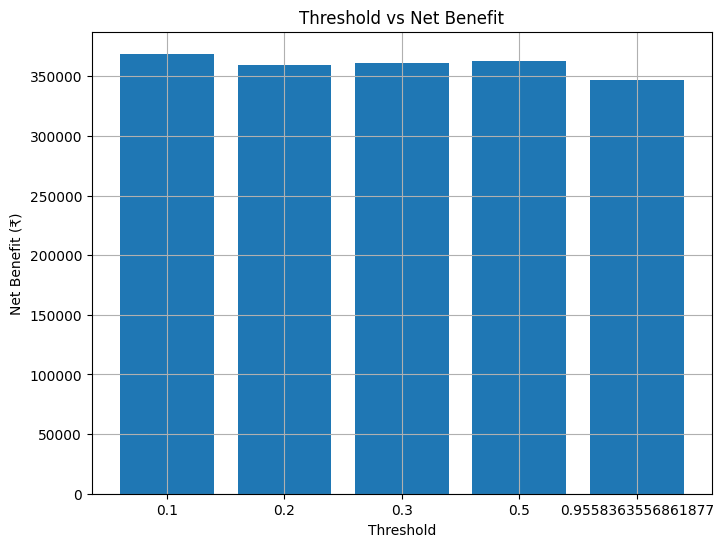

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.bar(
    business_df["Threshold"].astype(str),
    business_df["Net Benefit"]
)

plt.xlabel("Threshold")

plt.ylabel("Net Benefit (₹)")

plt.title("Threshold vs Net Benefit")

plt.grid(True)

plt.show()

In [27]:
best_threshold = 0.5

interpretation for a Paytm Risk Manager

You can use this in your report:

The threshold with the highest net benefit provides the best financial outcome by balancing fraud detection with investigation costs. Lower thresholds detect more fraudulent transactions but also generate more false alarms, increasing investigation expenses. Based on this analysis, Paytm should deploy the threshold that delivers the highest net benefit, as it maximizes overall financial savings rather than focusing only on technical model accuracy.